In [2]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sc.settings.figdir = "./plots"
sc.set_figure_params(dpi=100, dpi_save=100)

In [3]:
adata = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_celltype_pm_500k_filtered_.h5ad")

Consider running `set_figure_params(dpi_save=...)`, which will adjust `matplotlib.rcParams['savefig.dpi']`


/tmp/ipykernel_1903494/994628158.py:26: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


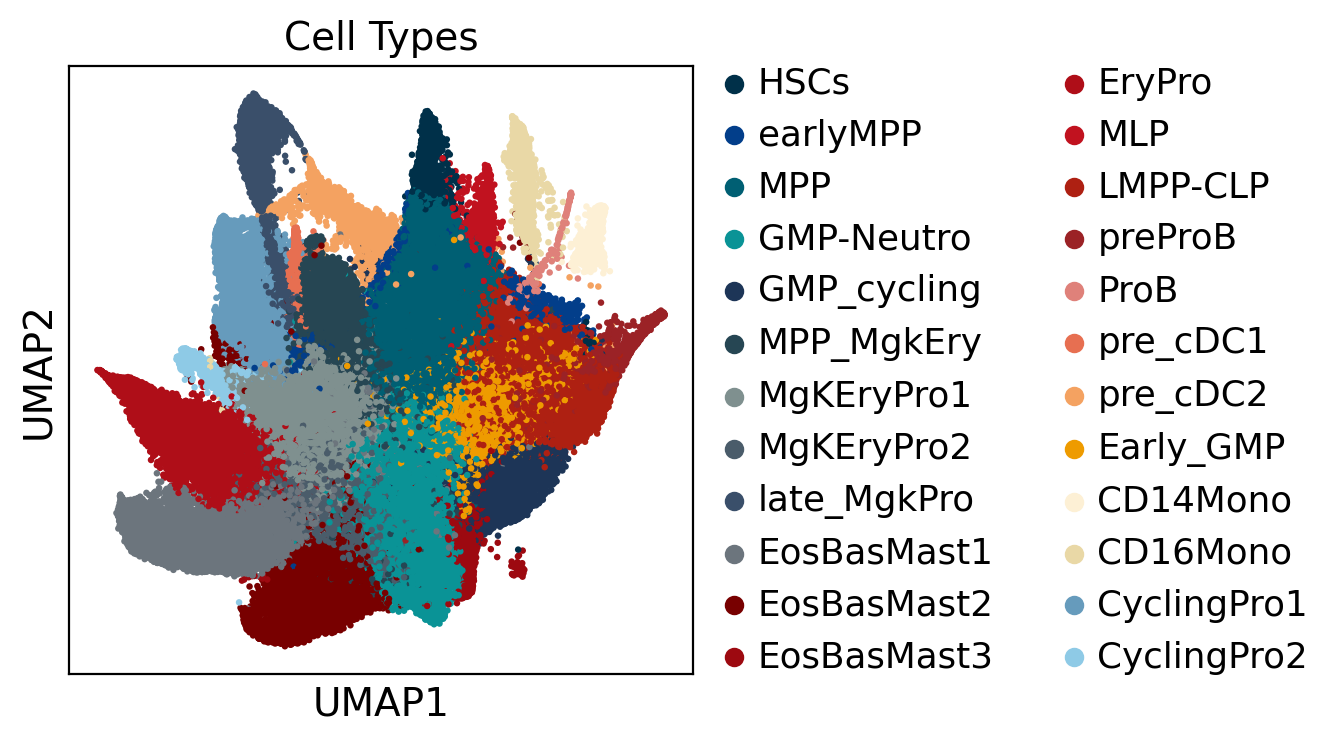

In [4]:
fierce_ocean_24 = [
    # deep ocean / space blues
    "#003049", "#023E8A", "#005F73", "#0A9396",
    "#1D3557", "#264653",

    # steel / slate neutrals
    "#7F908F", "#4A5C6A", "#3A4F6A", "#6C757D",

    # lava / reds
    "#780000", "#9D0910", "#AF0E18", "#C1121F",
    "#AE2012", "#9B2226",

    # coral / warm highlights
    "#DF817A", "#E76F51", "#F4A261", "#EE9B00",

    # sand / light neutrals
    "#FDF0D5", "#E9D8A6",

    # ocean light accents
    "#669BBC", "#8ECAE6",

    # bright contrast pop
    "#00B4D8", "#48CAE4"
]

sc.pl.umap(
    adata,
    color="cell_type",
    palette=fierce_ocean_24,
    s=22,
    title="Cell Types",
    save="_celltype.png", 
)

In [5]:
adata_full = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_Logicle_pm_.h5ad")

In [6]:
adata_full.X

array([[-0.01627393, -0.01365622,  0.05278862, ...,  0.4377564 ,
         0.18036887, -0.24454135],
       [-0.10760573,  0.0252714 ,  0.02106995, ...,  0.36247602,
        -0.03791661, -0.4383673 ],
       [-0.05484261,  0.00729571,  0.0556055 , ...,  0.14449732,
        -0.1061063 , -0.25002813],
       ...,
       [-0.03436854,  0.01355916,  0.01633156, ...,  0.46604487,
        -0.09529682, -0.4313756 ],
       [-0.3897775 ,  1.6319182 ,  0.04530682, ..., -0.00416615,
        -0.0617043 , -0.26081938],
       [-0.05324835,  0.9902931 ,  0.01315309, ..., -0.00392854,
         0.01435533,  0.116955  ]], shape=(52085765, 20), dtype=float32)

## Plot features 

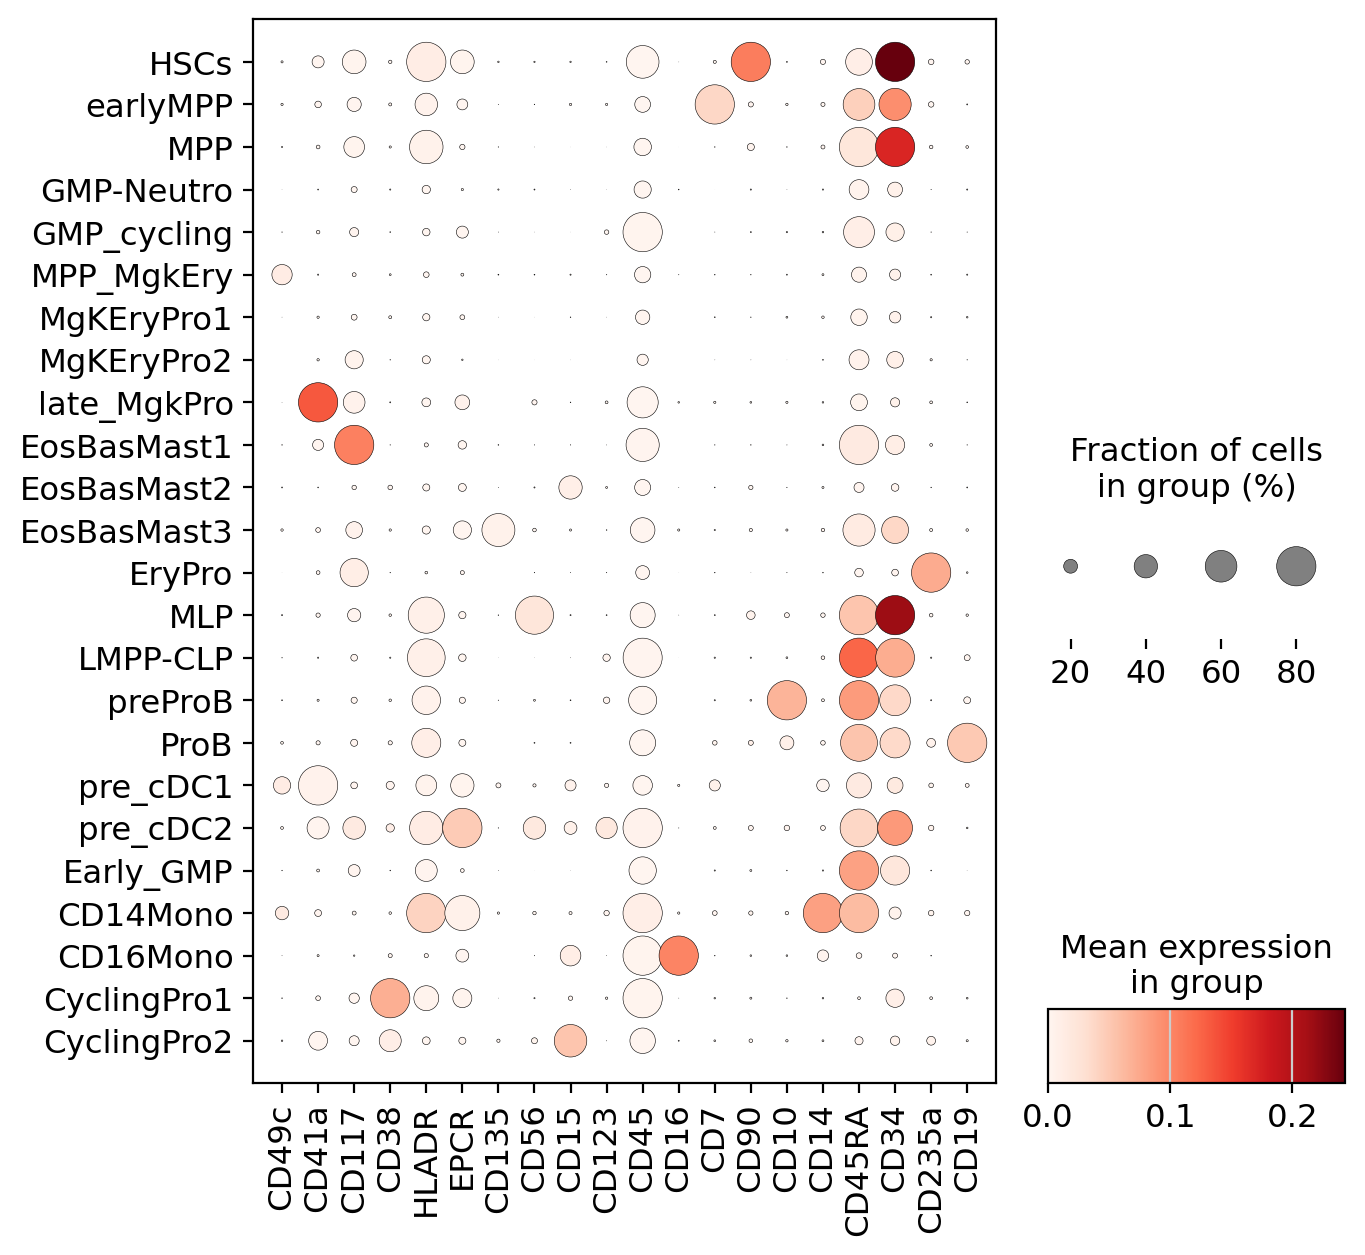

In [7]:
sc.pl.dotplot(
    adata,
    var_names=adata.var_names.tolist(),
    groupby="cell_type",
    figsize=(7, 7),
    dot_max=0.8,
    color_map="Reds",
)

/tmp/ipykernel_1903494/1448037714.py:26: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.dotplot(


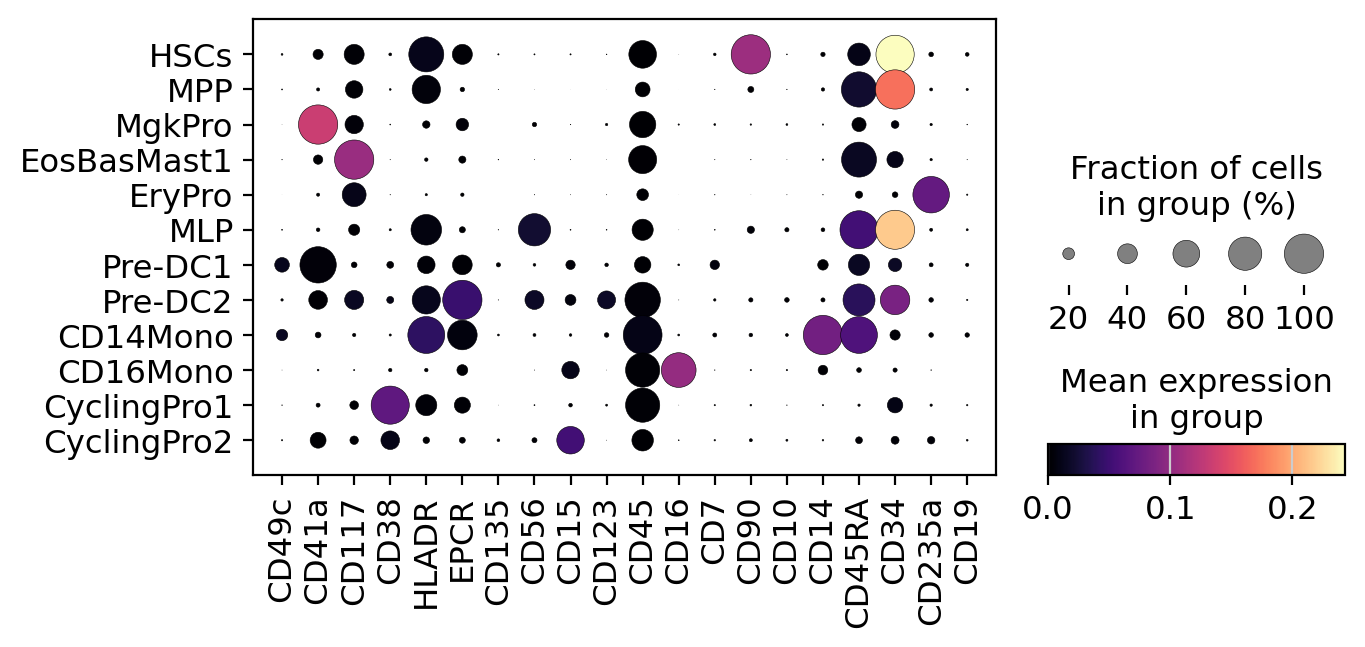

In [8]:
cell_types_of_interest = ["HSCs", 
                          "MPP", 
                          "late_MgkPro",
                          "EosBasMast1",
                          "EryPro", 
                          "MLP",
                          "proB", 
                          "pre_cDC1", 
                          "pre_cDC2",
                          "CD14Mono",
                          "CD16Mono", 
                          "CyclingPro1", 
                          "CyclingPro2"
                         ]  

rename_map = {
    "late_MgkPro": "MgkPro",
    "pre_cDC1": "Pre-DC1",
    "pre_cDC2": "Pre-DC2",
}

adata_sub = adata[adata.obs["cell_type"].isin(cell_types_of_interest)].copy()
adata_sub.obs["cell_type"] = adata_sub.obs["cell_type"].map(lambda x: rename_map.get(x, x))
adata.obs["cell_type"] = adata.obs["cell_type"].map(lambda x: rename_map.get(x, x))

sc.pl.dotplot(
    adata_sub,
    var_names=adata_sub.var_names.tolist(),
    groupby="cell_type",
    figsize=(7, 3),
    dot_max=1,
    cmap="magma",
    save="_marker_dotplot.svg",
)

In [9]:
np.unique(adata.obs.cell_type)

array(['CD14Mono', 'CD16Mono', 'CyclingPro1', 'CyclingPro2', 'Early_GMP',
       'EosBasMast1', 'EosBasMast2', 'EosBasMast3', 'EryPro',
       'GMP-Neutro', 'GMP_cycling', 'HSCs', 'LMPP-CLP', 'MLP', 'MPP',
       'MPP_MgkEry', 'MgKEryPro1', 'MgKEryPro2', 'MgkPro', 'Pre-DC1',
       'Pre-DC2', 'ProB', 'earlyMPP', 'preProB'], dtype=object)

/tmp/ipykernel_1903494/3959010197.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


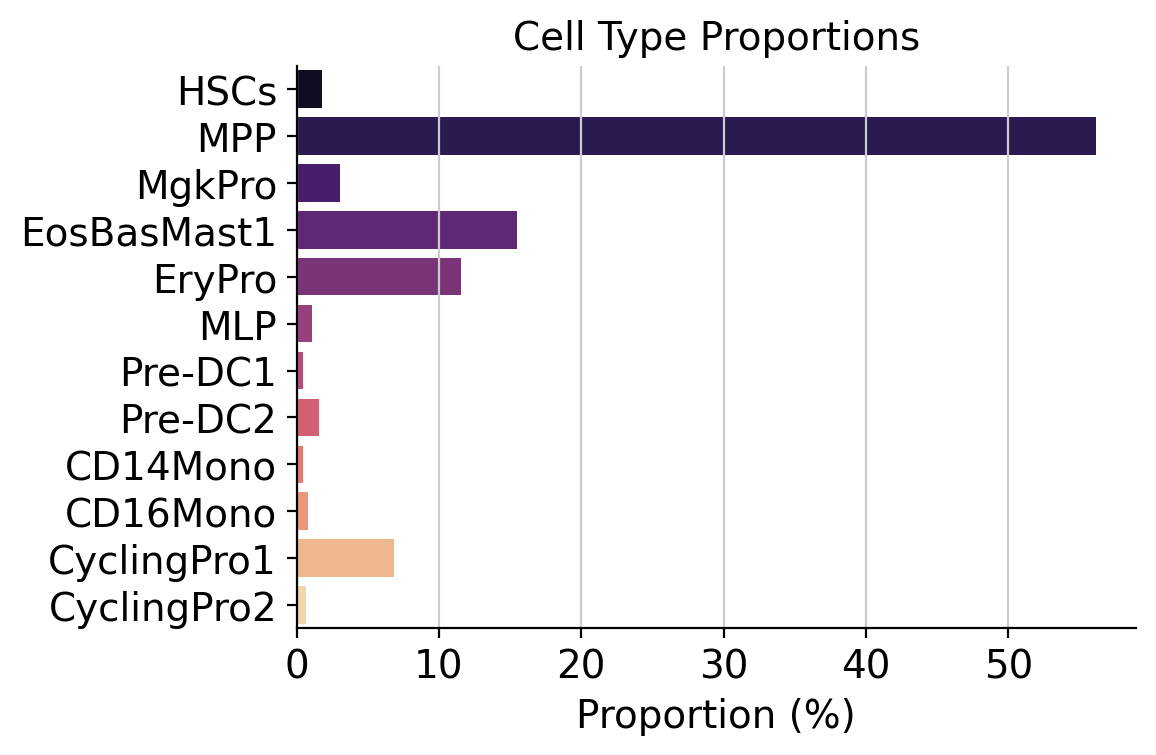

In [10]:
proportions = (
    adata_sub.obs["cell_type"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)
proportions.columns = ["cell_type", "proportion"]

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(
    data=proportions,
    y="cell_type",
    x="proportion",
    palette="magma",
    ax=ax
)

ax.set_xlabel("Proportion (%)")
ax.set_ylabel("")
ax.set_title("Cell Type Proportions")
sns.despine()
plt.tight_layout()

In [11]:
adata.uns

{'cell_type_colors': ['#003049',
  '#023e8a',
  '#005f73',
  '#0a9396',
  '#1d3557',
  '#264653',
  '#7f908f',
  '#4a5c6a',
  '#3a4f6a',
  '#6c757d',
  '#780000',
  '#9d0910',
  '#af0e18',
  '#c1121f',
  '#ae2012',
  '#9b2226',
  '#df817a',
  '#e76f51',
  '#f4a261',
  '#ee9b00',
  '#fdf0d5',
  '#e9d8a6',
  '#669bbc',
  '#8ecae6'],
 'leiden': {'modularity': 0.7243767843462762,
  'params': {'n_iterations': -1, 'random_state': 51, 'resolution': 1}},
 'leiden_colors': array(['#023fa5', '#7d87b9', '#bec1d4', '#d6bcc0', '#bb7784', '#8e063b',
        '#4a6fe3', '#8595e1', '#b5bbe3', '#e6afb9', '#e07b91', '#d33f6a',
        '#11c638', '#8dd593', '#c6dec7', '#ead3c6', '#f0b98d', '#ef9708',
        '#0fcfc0', '#9cded6', '#d5eae7', '#f3e1eb', '#f79cd4', '#7f7f7f'],
       dtype=object),
 'leiden_colors_old': array(['#023fa5', '#7d87b9', '#bec1d4', '#d6bcc0', '#bb7784', '#8e063b',
        '#4a6fe3', '#8595e1', '#b5bbe3', '#e6afb9', '#e07b91', '#d33f6a',
        '#11c638', '#8dd593', '#c6dec7', '#e

In [12]:
dict(zip(adata.uns["cell_type_colors"], adata.obs.cell_type.cat.categories))

{'#003049': 'HSCs',
 '#023e8a': 'earlyMPP',
 '#005f73': 'MPP',
 '#0a9396': 'GMP-Neutro',
 '#1d3557': 'GMP_cycling',
 '#264653': 'MPP_MgkEry',
 '#7f908f': 'MgKEryPro1',
 '#4a5c6a': 'MgKEryPro2',
 '#3a4f6a': 'MgkPro',
 '#6c757d': 'EosBasMast1',
 '#780000': 'EosBasMast2',
 '#9d0910': 'EosBasMast3',
 '#af0e18': 'EryPro',
 '#c1121f': 'MLP',
 '#ae2012': 'LMPP-CLP',
 '#9b2226': 'preProB',
 '#df817a': 'ProB',
 '#e76f51': 'Pre-DC1',
 '#f4a261': 'Pre-DC2',
 '#ee9b00': 'Early_GMP',
 '#fdf0d5': 'CD14Mono',
 '#e9d8a6': 'CD16Mono',
 '#669bbc': 'CyclingPro1',
 '#8ecae6': 'CyclingPro2'}

/tmp/ipykernel_1903494/2388764209.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1903494/2388764209.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")


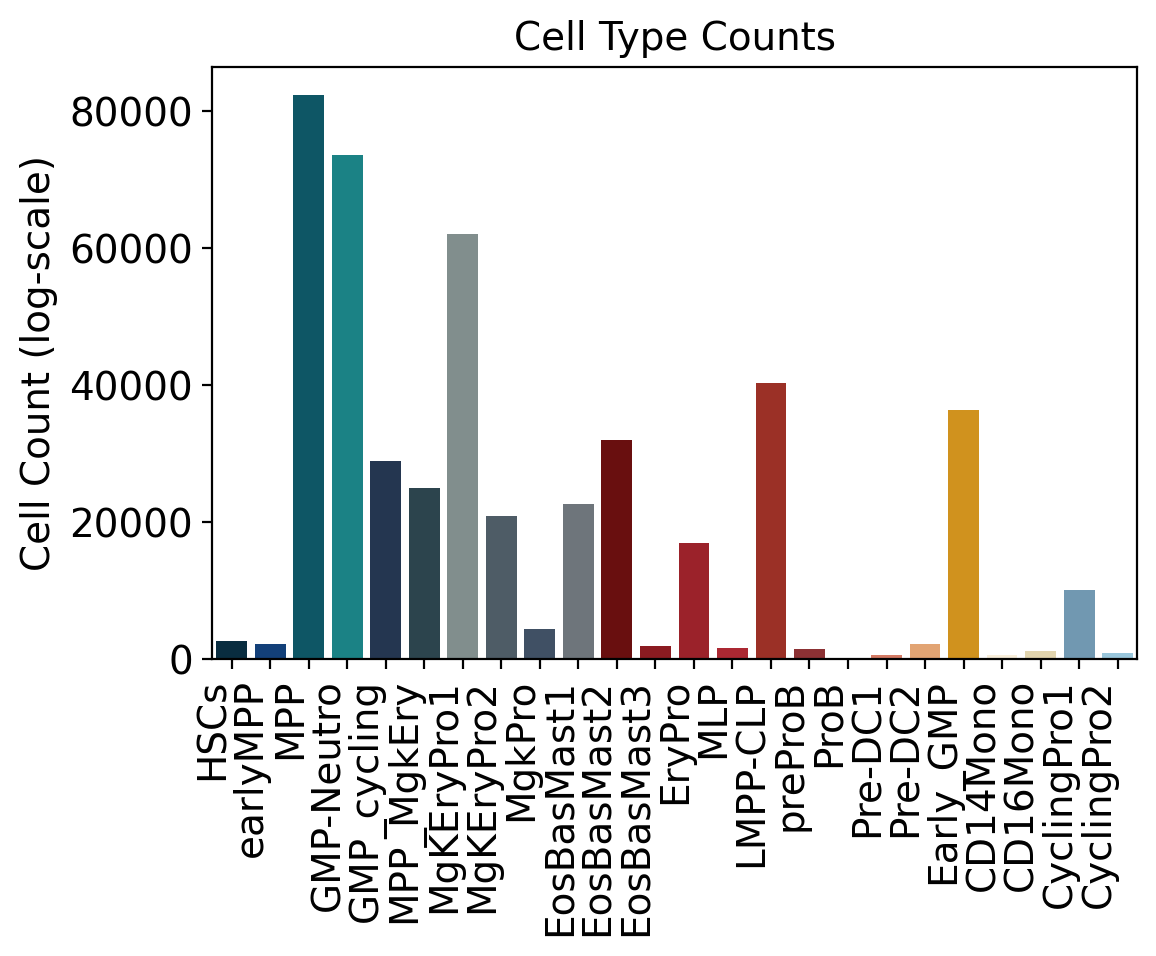

In [13]:
color_map = {
    'HSCs': '#003049',
    'earlyMPP': '#023e8a',
    'MPP': '#005f73',
    'GMP-Neutro': '#0a9396',
    'GMP_cycling': '#1d3557',
    'MPP_MgkEry': '#264653',
    'MgKEryPro1': '#7f908f',
    'MgKEryPro2': '#4a5c6a',
    'MgkPro': '#3a4f6a',
    'EosBasMast1': '#6c757d',
    'EosBasMast2': '#780000',
    'EosBasMast3': '#9d0910',
    'EryPro': '#af0e18',
    'MLP': '#c1121f',
    'LMPP-CLP': '#ae2012',
    'preProB': '#9b2226',
    'ProB': '#df817a',
    'Pre-DC1': '#e76f51',
    'Pre-DC2': '#f4a261',
    'Early_GMP': '#ee9b00',
    'CD14Mono': '#fdf0d5',
    'CD16Mono': '#e9d8a6',
    'CyclingPro1': '#669bbc',
    'CyclingPro2': '#8ecae6',
}

counts = (
    adata.obs["cell_type"]
    .value_counts()
    .reset_index()
)
counts.columns = ["cell_type", "count"]

fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(
    data=counts,
    y="count",
    x="cell_type",
    palette={ct: color_map[ct] for ct in counts["cell_type"]},
    ax=ax
)

ax.set_xlabel("")
ax.set_ylabel("Cell Count (log-scale)")
ax.set_title("Cell Type Counts")
# ax.set_yscale("log")
ax.grid(False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")
plt.tight_layout()
plt.savefig("./plots/cell_type_counts.svg")
plt.show()

In [32]:
X_morph = adata_sub.obs.loc[:, ['FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width']].values

adata_morph = sc.AnnData(X=np.log1p(X_morph), obs=adata_sub.obs)
adata_morph.var.index = ['FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width']

In [33]:
adata_morph.obs = adata_morph.obs.drop(adata_morph.var.index, axis=1)

/tmp/ipykernel_1903494/1025813056.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.dotplot(


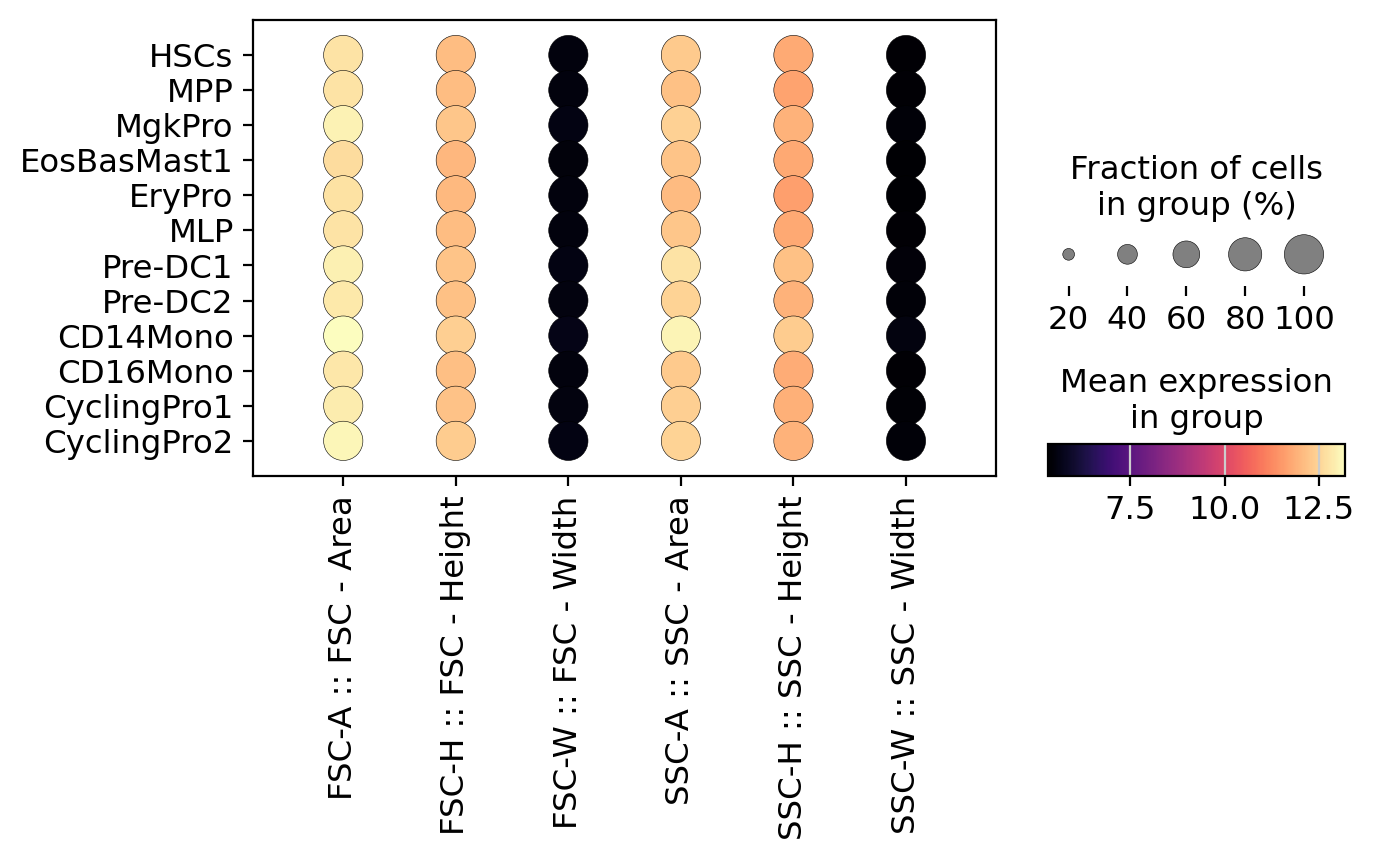

In [34]:
sc.pl.dotplot(
    adata_morph,
    var_names=adata_morph.var_names.tolist(),
    groupby="cell_type",
    figsize=(7, 3),
    dot_max=1,
    cmap="magma",
    save="_marker_dotplot.svg",
)